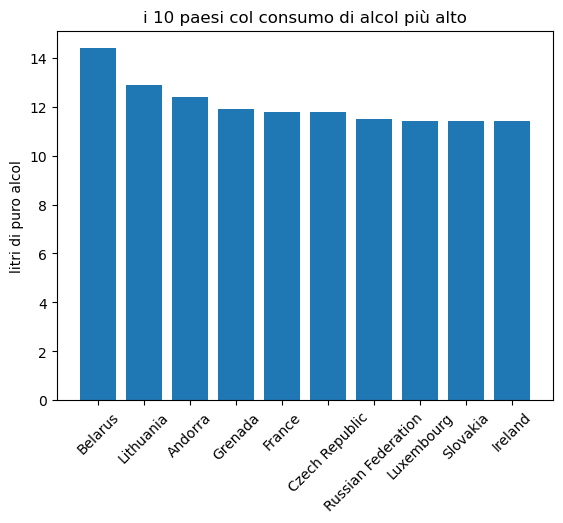

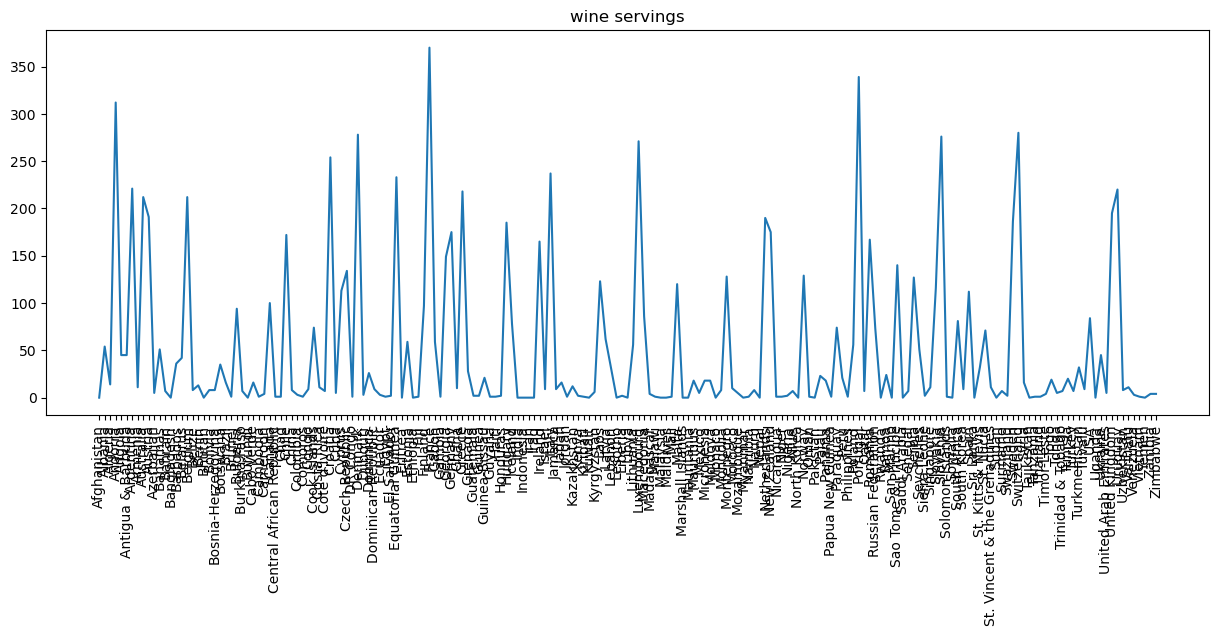

(                country  beer_servings  spirit_servings  wine_servings  \
 15              Belarus            142              373             42   
 98            Lithuania            343              244             56   
 3               Andorra            245              138            312   
 68              Grenada            199              438             28   
 61               France            127              151            370   
 45       Czech Republic            361              170            134   
 141  Russian Federation            247              326             73   
 99           Luxembourg            236              133            271   
 155            Slovakia            196              293            116   
 81              Ireland            313              118            165   
 
      total_litres_of_pure_alcohol  
 15                           14.4  
 98                           12.9  
 3                            12.4  
 68                      

In [48]:
import pandas as pd

import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")


#1.Consumo di alcol per paese

top10_cunsumatori_alcol = df.sort_values('total_litres_of_pure_alcohol',ascending=False).head(10)

medie = df[['beer_servings', 'wine_servings', 'spirit_servings']].mean()

#aggiungo nuova colonna
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3

max_alcohol_index = df['alcohol_index'].max()

oltre_100_birre = df[df['beer_servings'] > 100]

#grafico a barre dei 10 paesi con più consumo di alcol
plt.bar(top10_cunsumatori_alcol['country'], top10_cunsumatori_alcol['total_litres_of_pure_alcohol'] )
plt.title('i 10 paesi col consumo di alcol più alto')
plt.xticks(rotation = 45)
plt.ylabel('litri di puro alcol')
plt.show()

#grafico di wine serving ordinato per paese
df_paesi_ordinati = df.sort_values('country')
#allargo la dimensione rispetto al default
plt.figure(figsize=(15,5))
plt.plot(df_paesi_ordinati['country'], df_paesi_ordinati['wine_servings'])
plt.title('wine servings')
plt.xticks(rotation = 90)

plt.show()



#risultati
top10_cunsumatori_alcol, medie, df, max_alcohol_index, oltre_100_birre


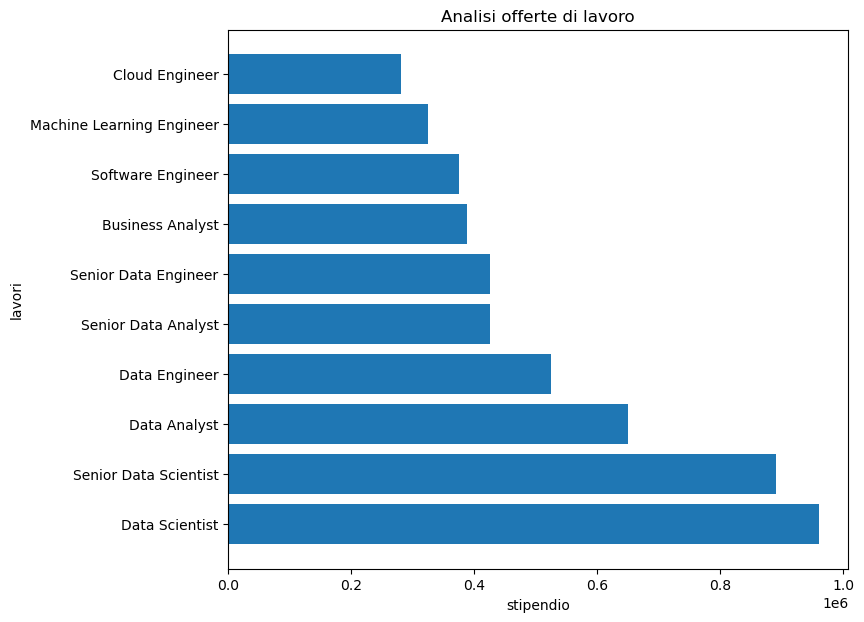

(np.float64(123286.27407182401), np.int64(22003), 15000.0, 960000.0)

In [71]:
#2.Analisi offerte lavoro

from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
#tolgo i NaN
df_pulito = df.dropna(subset =  ['salary_year_avg'])

media = df_pulito['salary_year_avg'].mean()

job_count = df_pulito['salary_year_avg'].count()

min = df_pulito['salary_year_avg'].min()

max = df_pulito['salary_year_avg'].max()
#ordino dallo stipendio maggiore a quello minore
df_stipendio_ordinato = df_pulito.sort_values('salary_year_avg', ascending = False)

plt.figure(figsize=(8,7))
plt.barh(df_stipendio_ordinato['job_title_short'], df_stipendio_ordinato['salary_year_avg'])
plt.title('Analisi offerte di lavoro')
plt.xlabel('stipendio')
plt.ylabel('lavori')
plt.show()
#risultati
media, job_count, min, max, 



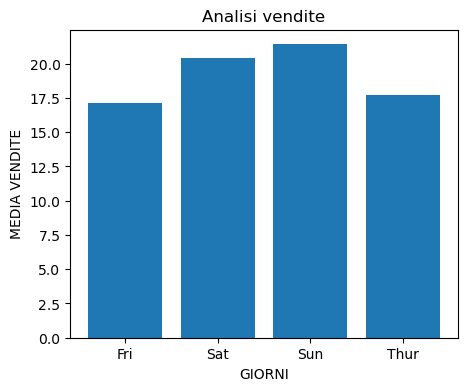

(np.float64(19.78594262295082),
 244,
 3.07,
 50.81,
 'Sun',
      total_bill   tip     sex smoker   day    time  size  conto_per_persona
 0         16.99  1.01  Female     No   Sun  Dinner     2           8.495000
 1         10.34  1.66    Male     No   Sun  Dinner     3           3.446667
 2         21.01  3.50    Male     No   Sun  Dinner     3           7.003333
 3         23.68  3.31    Male     No   Sun  Dinner     2          11.840000
 4         24.59  3.61  Female     No   Sun  Dinner     4           6.147500
 ..          ...   ...     ...    ...   ...     ...   ...                ...
 239       29.03  5.92    Male     No   Sat  Dinner     3           9.676667
 240       27.18  2.00  Female    Yes   Sat  Dinner     2          13.590000
 241       22.67  2.00    Male    Yes   Sat  Dinner     2          11.335000
 242       17.82  1.75    Male     No   Sat  Dinner     2           8.910000
 243       18.78  3.00  Female     No  Thur  Dinner     2           9.390000
 
 [244 rows x 

In [91]:
#3.Analisi vendite

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

media = df['total_bill'].mean()
#numero di righe
osservazioni = df.shape[0]

min = df['total_bill'].min()

max = df['total_bill'].max()

df['conto_per_persona'] = df['total_bill']/df['size']

giorno_conto_medio_max = df.groupby('day')['total_bill'].mean().idxmax()
#valori ordinato dal più grande al più piccolo
df_ordinato = df.sort_values('total_bill', ascending=False)

media_giorno = df.groupby('day')['total_bill'].mean()

plt.figure(figsize=(5,4))
plt.bar(media_giorno.index, media_giorno.values)
plt.title('Analisi vendite')
plt.xlabel('GIORNI')
plt.ylabel('MEDIA VENDITE')
plt.show()


#risultati
media, osservazioni, min, max, giorno_conto_medio_max, df